## Notebook summary

| Item | Details |
| --- | --- |
| Purpose | 04 - Locked YOLO ROI Test Evaluation with Grad-CAM |
| Model | SE-ResNeXt-50 32x4d |
| Input | 384x384 YOLO ROI |
| Dataset | DenseNet121 YOLO square ROI test split |
| Loss | Cross-Entropy (CE) |
| Status | evaluation-only notebook |


# 04 - Locked YOLO ROI Test Evaluation with Grad-CAM

This notebook evaluates the SE-ResNeXt-50 checkpoint from notebook 03 on the **untouched YOLO ROI test split**.

It does not train, tune, or overwrite checkpoints.

It saves:
- Classification metrics (QWK, F1, AP, accuracy)
- Confusion matrix heatmap
- Grad-CAM heatmaps for **correct** predictions (grouped by true grade)
- Grad-CAM heatmaps for **misclassified** cases (side-by-side true vs predicted pairs)

**IMPORTANT:** The test set is locked. Do not use these metrics to choose another epoch or preprocessing setting.

In [1]:
!pip -q install "timm>=1.0"

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import json
import random
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    cohen_kappa_score, confusion_matrix,
    precision_recall_fscore_support, recall_score, roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Fixed evaluation configuration

The checkpoint path is the selected epoch from notebook 03. Keep the test split locked.

In [3]:
INPUT_SIZE = 384
NUM_CLASSES = 5
BATCH_SIZE = 48
NUM_WORKERS = 2

# --- PATHS ---
# Resolve the newest checkpoint produced by Notebook 03.
ADAPTATION_ROOT = Path("/content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384")
adaptation_checkpoints = sorted(
    ADAPTATION_ROOT.glob("*/best_model.pth"),
    key=lambda path: path.stat().st_mtime, reverse=True,
)
if not adaptation_checkpoints:
    raise FileNotFoundError(
        f"No Notebook 03 checkpoint found under {ADAPTATION_ROOT}. "
        "Run 03_train_se_resnext50_yolo_roi_384 first."
    )
CHECKPOINT_PATH = adaptation_checkpoints[0]

# YOLO ROI test split
TEST_ROOT = Path(
    "/content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1/"
    "derived/densenet121_yolo_square_roi_trainvaltest_v2/test"
)

# Output directory
OUTPUT_TIMESTAMP = datetime.now(timezone.utc).strftime("%Y-%m-%d_%H-%M-%S_%f_UTC")
OUTPUT_DIR = CHECKPOINT_PATH.parent / f"evaluation_{OUTPUT_TIMESTAMP}"

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}\n"
        f"Update CHECKPOINT_PATH in the config cell to point to your notebook 03 output."
    )
if not TEST_ROOT.exists():
    raise FileNotFoundError(f"Test dataset not found: {TEST_ROOT}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Test dataset: {TEST_ROOT}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
Checkpoint: /content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384/2026-08-14_23-59-46_940080_UTC/best_model.pth
Test dataset: /content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1/derived/densenet121_yolo_square_roi_trainvaltest_v2/test
Output: /content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384/2026-08-14_23-59-46_940080_UTC/evaluation_2026-08-15_00-34-38_857832_UTC


## Build test dataset

In [4]:
test_rows = []
for grade in range(5):
    grade_dir = TEST_ROOT / str(grade)
    if not grade_dir.exists():
        continue
    for roi_path in sorted(grade_dir.glob("*.png")):
        test_rows.append({
            "grade": grade,
            "roi_path": str(roi_path),
        })

test_frame = pd.DataFrame(test_rows)
print(f"Total test samples: {len(test_frame)}")
print(test_frame.groupby("grade").size())

Total test samples: 1656
grade
0    639
1    296
2    447
3    223
4     51
dtype: int64


## Preprocessing

In [5]:
class OpenCVCLAHE:
    def __call__(self, image_rgb):
        lab = cv2.cvtColor(np.asarray(image_rgb), cv2.COLOR_RGB2LAB)
        lightness, a, b = cv2.split(lab)
        lightness = cv2.createCLAHE(clipLimit=1.25, tileGridSize=(8, 8)).apply(lightness)
        return cv2.cvtColor(cv2.merge((lightness, a, b)), cv2.COLOR_LAB2RGB)

class SquarePad:
    def __call__(self, image_rgb):
        image = np.asarray(image_rgb)
        height, width = image.shape[:2]
        side = max(height, width)
        top, left = (side - height) // 2, (side - width) // 2
        return cv2.copyMakeBorder(
            image, top, side - height - top,
            left, side - width - left,
            cv2.BORDER_CONSTANT, value=(0, 0, 0)
        )

test_transform = transforms.Compose([
    OpenCVCLAHE(), SquarePad(), transforms.ToPILImage(),
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class ROITestDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        image = cv2.imread(row.roi_path, cv2.IMREAD_COLOR)
        if image is None:
            raise IOError(f"Cannot read image: {row.roi_path}")
        return (
            self.transform(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)),
            int(row.grade),
            row.roi_path,
        )

## Model — load checkpoint

In [6]:
class SEResNeXt50Model(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model(
            "seresnext50_32x4d",
            pretrained=False,
            features_only=True,
            out_indices=(4,),
        )
        channels = self.backbone.feature_info.channels()[0]
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, images):
        features = self.backbone(images)[0]
        return self.classifier(features.mean(dim=(2, 3)))

    @property
    def gradcam_target_layer(self):
        # Last convolutional layer of SE-ResNeXt-50: the final conv in layer4[-1]
        return self.backbone.layer4[-1].conv3


model = SEResNeXt50Model(num_classes=NUM_CLASSES).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
if ckpt.get("architecture") not in (None, "seresnext50_32x4d_linear_gradcam"):
    raise RuntimeError(f"Unexpected checkpoint architecture: {ckpt.get('architecture')}")
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded: {CHECKPOINT_PATH}")
print(f"Architecture: {ckpt.get('architecture', 'N/A')}")
print(f"Selection: {ckpt.get('selection', 'N/A')}")
print(f"Stage: {ckpt.get('stage', 'N/A')}")

Loaded: /content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384/2026-08-14_23-59-46_940080_UTC/best_model.pth
Architecture: seresnext50_32x4d_linear_gradcam
Selection: N/A
Stage: N/A


## Evaluation

In [7]:
test_dataset = ROITestDataset(test_frame, test_transform)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

all_labels = []
all_preds = []
all_probs = []
all_paths = []

with torch.inference_mode():
    for images, labels, paths in tqdm(test_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_paths.extend(paths)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
print(f"\nEvaluation complete. Total samples: {len(all_labels)}")

Evaluating:   0%|          | 0/35 [00:00<?, ?it/s]


Evaluation complete. Total samples: 1656


## Metrics

In [9]:
accuracy    = accuracy_score(all_labels, all_preds)
qwk         = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
_, _, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)
macro_ap    = average_precision_score(
    F.one_hot(torch.tensor(all_labels), num_classes=NUM_CLASSES).numpy(),
    all_probs, average="macro"
)
try:
    roc_auc = roc_auc_score(
        F.one_hot(torch.tensor(all_labels), num_classes=NUM_CLASSES).numpy(),
        all_probs, average="macro"
    )
except Exception:
    roc_auc = float("nan")

metrics = {
    "accuracy": float(accuracy),
    "qwk": float(qwk),
    "macro_f1": float(macro_f1),
    "macro_ap": float(macro_ap),
    "roc_auc": float(roc_auc),
    "n_test": len(all_labels),
}

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)
print(f"Model: SE-ResNeXt-50 32x4d")
print(f"Input: {INPUT_SIZE}x{INPUT_SIZE} YOLO ROI")
print("=" * 60)
for k, v in metrics.items():
    print(f"  {k:12s}: {v:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4,
    target_names=["KL0", "KL1", "KL2", "KL3", "KL4"]))

EVALUATION RESULTS
Model: SE-ResNeXt-50 32x4d
Input: 384x384 YOLO ROI
  accuracy    : 0.5876
  qwk         : 0.7437
  macro_f1    : 0.6079
  macro_ap    : 0.6377
  roc_auc     : 0.8507
  n_test      : 1656.0000

Classification Report:
              precision    recall  f1-score   support

         KL0     0.6900    0.7418    0.7149       639
         KL1     0.2629    0.3277    0.2917       296
         KL2     0.6111    0.4430    0.5136       447
         KL3     0.7385    0.7220    0.7302       223
         KL4     0.7414    0.8431    0.7890        51

    accuracy                         0.5876      1656
   macro avg     0.6088    0.6155    0.6079      1656
weighted avg     0.6005    0.5876    0.5893      1656



## Confusion Matrix

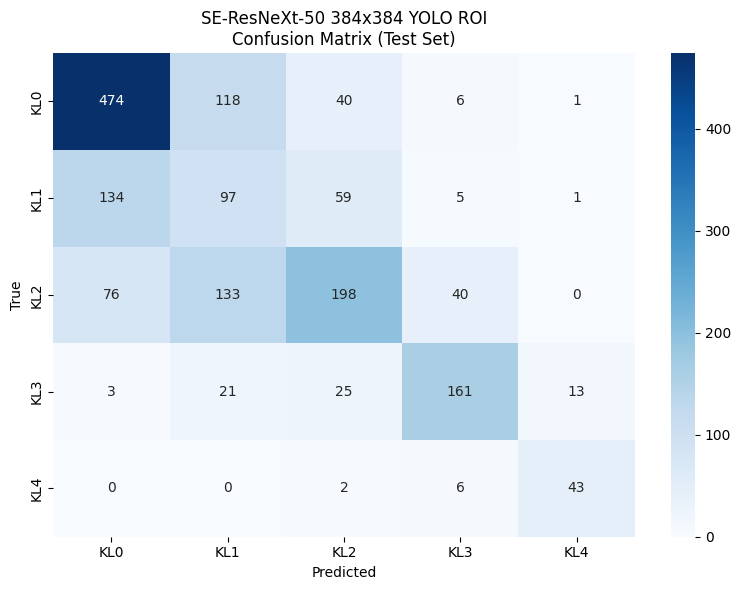


Confusion Matrix:
[[474 118  40   6   1]
 [134  97  59   5   1]
 [ 76 133 198  40   0]
 [  3  21  25 161  13]
 [  0   0   2   6  43]]


In [10]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["KL0", "KL1", "KL2", "KL3", "KL4"],
    yticklabels=["KL0", "KL1", "KL2", "KL3", "KL4"],
)
plt.title("SE-ResNeXt-50 384x384 YOLO ROI\nConfusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

print("\nConfusion Matrix:")
print(cm)

## Grad-CAM — setup

In [11]:
class SEResNeXtGradCAM:
    """Grad-CAM for SE-ResNeXt-50 using layer4[-1].conv3 as target."""

    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None
        self.handle = model.gradcam_target_layer.register_forward_hook(self._capture_activation)

    def _capture_activation(self, module, inputs, output):
        self.activations = output
        output.register_hook(self._capture_gradient)

    def _capture_gradient(self, grad):
        self.gradients = grad

    def compute_cam(self, images, class_idx):
        """Return spatial CAM map (H, W) for the given class."""
        images = images.to(DEVICE)
        images.requires_grad_(True)
        self.model.zero_grad()
        output = self.model(images)
        self.model.zero_grad()
        # Backprop from the target class logit
        class_score = output[0, class_idx]
        class_score.backward(retain_graph=True)
        # Global average pool the gradients weighted by activations
        grad = self.gradients[0].cpu().data.numpy()  # (C, H, W)
        act  = self.activations[0].cpu().data.numpy() # (C, H, W)
        weights = grad.mean(axis=(1, 2))             # (C,)
        cam = np.maximum(
            (weights[:, None, None] * act).sum(axis=0),
            0
        )
        # Normalise to [0, 1]
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam  # (H, W)

    def remove(self):
        self.handle.remove()


def prepare_roi(path):
    """Load and preprocess one ROI image for Grad-CAM."""
    image_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    # CLAHE + squarepad + resize (same as test_transform but split for overlay)
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_LAB2RGB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=1.25, tileGridSize=(8, 8)).apply(l)
    processed = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    h, w = processed.shape[:2]
    side = max(h, w)
    pad = cv2.copyMakeBorder(
        processed, (side - h) // 2, side - h - (side - h) // 2,
        (side - w) // 2, side - w - (side - w) // 2,
        cv2.BORDER_CONSTANT, value=(0, 0, 0)
    )
    resized = cv2.resize(pad, (INPUT_SIZE, INPUT_SIZE))
    tensor = transforms.ToTensor()(resized)
    tensor = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )(tensor)
    return processed, tensor


def cam_overlay(rgb, cam, alpha=0.40):
    """Blend CAM heatmap onto the original image."""
    cam_up = cv2.resize(cam, (INPUT_SIZE, INPUT_SIZE))
    heatmap = cv2.applyColorMap(
        (cam_up * 255).astype(np.uint8), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    blended = (rgb * (1 - alpha) + heatmap * alpha / 255.0 * 255).astype(np.uint8)
    return blended


def render_case(path, class_idx, cam_impl):
    """Return (original_rgb, cam_overlay_rgb) for one image."""
    _, tensor = prepare_roi(path)
    cam = cam_impl.compute_cam(tensor.unsqueeze(0), class_idx)
    _, tensor_rgb = prepare_roi(path)  # get processed RGB for overlay
    # Rebuild RGB for overlay
    image_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_LAB2RGB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=1.25, tileGridSize=(8, 8)).apply(l)
    processed = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    h, w = processed.shape[:2]
    side = max(h, w)
    pad = cv2.copyMakeBorder(
        processed, (side - h) // 2, side - h - (side - h) // 2,
        (side - w) // 2, side - w - (side - w) // 2,
        cv2.BORDER_CONSTANT, value=(0, 0, 0)
    )
    resized = cv2.resize(pad, (INPUT_SIZE, INPUT_SIZE))
    overlay = cam_overlay(resized, cam)
    return resized, overlay

## Grad-CAM — correct and misclassified cases

In [12]:
gradcam = SEResNeXtGradCAM(model)

correct_dir  = OUTPUT_DIR / "gradcam_correct_by_true_grade"
incorrect_dir = OUTPUT_DIR / "gradcam_misclassified_pairs"
correct_dir.mkdir()
incorrect_dir.mkdir()

# Group correct predictions by true grade
correct_by_grade = {g: [] for g in range(NUM_CLASSES)}
for i in range(len(all_labels)):
    if all_preds[i] == all_labels[i]:
        correct_by_grade[all_labels[i]].append(i)

# Collect misclassified
misclassified_rows = []

for i in tqdm(range(len(all_labels)), desc="Generating Grad-CAM"):
    true_label = int(all_labels[i])
    pred_label = int(all_preds[i])
    path = all_paths[i]

    if true_label == pred_label:
        # Save up to 8 correct cases per true grade
        if len(correct_by_grade[true_label]) <= 8:
            rgb, overlay = render_case(path, true_label, gradcam)
            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(rgb)
            axes[0].set_title(f"Input  (true=KL{true_label})")
            axes[0].axis("off")
            axes[1].imshow(overlay)
            axes[1].set_title(f"Grad-CAM KL{true_label}")
            axes[1].axis("off")
            plt.suptitle(f"Correct KL{true_label} — {Path(path).name}")
            plt.tight_layout()
            out_path = correct_dir / f"correct_KL{true_label}_{Path(path).name}.png"
            plt.savefig(out_path, dpi=120, bbox_inches="tight")
            plt.close()
    else:
        # Misclassified: save side-by-side pair
        rgb_true, overlay_true = render_case(path, true_label, gradcam)
        rgb_pred, overlay_pred = render_case(path, pred_label, gradcam)
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].imshow(rgb_true)
        axes[0].set_title(f"Input (true=KL{true_label})")
        axes[0].axis("off")
        axes[1].imshow(overlay_true)
        axes[1].set_title(f"CAM for KL{true_label}")
        axes[1].axis("off")
        axes[2].imshow(rgb_pred)
        axes[2].set_title(f"Input (pred=KL{pred_label})")
        axes[2].axis("off")
        axes[3].imshow(overlay_pred)
        axes[3].set_title(f"CAM for KL{pred_label}")
        axes[3].axis("off")
        plt.suptitle(
            f"MISCLASSIFIED — true KL{true_label}, predicted KL{pred_label} — {Path(path).name}",
            fontsize=11
        )
        plt.tight_layout()
        output_path = incorrect_dir / f"miss_KL{true_label}_predKL{pred_label}_{Path(path).name}.png"
        plt.savefig(output_path, dpi=120, bbox_inches="tight")
        plt.close()
        misclassified_rows.append({
            "path": path,
            "true_grade": true_label,
            "predicted_grade": pred_label,
            "cam_pair_path": str(output_path),
        })

gradcam.remove()

# Summary per grade
print("\nCorrect predictions per true grade:")
for g in range(NUM_CLASSES):
    print(f"  KL{g}: {len(correct_by_grade[g])} correct")
print(f"\nMisclassified total: {len(misclassified_rows)}")
print("\nMisclassified distribution (true -> predicted):")
pd.DataFrame(misclassified_rows).to_csv(
    OUTPUT_DIR / "gradcam_misclassified_index.csv", index=False
)
print(f"Correct Grad-CAM grids: {correct_dir}")
print(f"Misclassified CAM pairs: {incorrect_dir}")

Generating Grad-CAM:   0%|          | 0/1656 [00:00<?, ?it/s]


Correct predictions per true grade:
  KL0: 474 correct
  KL1: 97 correct
  KL2: 198 correct
  KL3: 161 correct
  KL4: 43 correct

Misclassified total: 683

Misclassified distribution (true -> predicted):
Correct Grad-CAM grids: /content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384/2026-08-14_23-59-46_940080_UTC/evaluation_2026-08-15_00-34-38_857832_UTC/gradcam_correct_by_true_grade
Misclassified CAM pairs: /content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384/2026-08-14_23-59-46_940080_UTC/evaluation_2026-08-15_00-34-38_857832_UTC/gradcam_misclassified_pairs


## Save evaluation package

In [13]:
results = {
    "checkpoint": str(CHECKPOINT_PATH),
    "architecture": ckpt.get("architecture", "seresnext50_32x4d_linear_gradcam"),
    "stage": ckpt.get("stage", "N/A"),
    "test_samples": len(test_frame),
    **metrics,
    "correct_gradcam_dir": str(correct_dir),
    "misclassified_gradcam_dir": str(incorrect_dir),
}
with open(OUTPUT_DIR / "evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

manifest = {
    "model": "seresnext50_32x4d",
    "input_size": INPUT_SIZE,
    "preprocessing": "CLAHE(1.25) -> squarepad -> resize(384) -> ImageNet norm",
    "evaluation_only": True,
    "metrics": metrics,
    "correct_gradcam_directory": str(correct_dir),
    "misclassified_gradcam_directory": str(incorrect_dir),
}
(OUTPUT_DIR / "evaluation_manifest.json").write_text(
    json.dumps(manifest, indent=2)
)

print("=" * 60)
print("EVALUATION COMPLETE")
print("=" * 60)
print(f"Test samples:   {metrics['n_test']}")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
print(f"QWK:            {metrics['qwk']:.4f}")
print(f"Macro F1:       {metrics['macro_f1']:.4f}")
print(f"Macro AP:       {metrics['macro_ap']:.4f}")
print(f"ROC-AUC:        {metrics['roc_auc']:.4f}")
print("=" * 60)
print(f"Results:  {OUTPUT_DIR / 'evaluation_results.json'}")
print(f"Confusion matrix: {OUTPUT_DIR / 'confusion_matrix.png'}")
print(f"Correct Grad-CAM: {correct_dir}")
print(f"Misclassified CAM: {incorrect_dir}")
print("=" * 60)

EVALUATION COMPLETE
Test samples:   1656
Accuracy:        0.5876
QWK:            0.7437
Macro F1:       0.6079
Macro AP:       0.6377
ROC-AUC:        0.8507
Results:  /content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384/2026-08-14_23-59-46_940080_UTC/evaluation_2026-08-15_00-34-38_857832_UTC/evaluation_results.json
Confusion matrix: /content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384/2026-08-14_23-59-46_940080_UTC/evaluation_2026-08-15_00-34-38_857832_UTC/confusion_matrix.png
Correct Grad-CAM: /content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384/2026-08-14_23-59-46_940080_UTC/evaluation_2026-08-15_00-34-38_857832_UTC/gradcam_correct_by_true_grade
Misclassified CAM: /content/drive/MyDrive/Models/seresnext50_32x4d_yolo_384/2026-08-14_23-59-46_940080_UTC/evaluation_2026-08-15_00-34-38_857832_UTC/gradcam_misclassified_pairs
